# Notes from AIMA20 Chapter 5 - Adversarial Search and Games

## Background on AND-OR search (from CH4)

# AND-OR Search

AND-OR search is used in nondeterministic environments where actions may have multiple possible outcomes. Because the result of an action is uncertain, a fixed sequence of actions is insufficient; instead, the solution must handle all possible outcomes.

## Structure of AND-OR Trees

The search tree alternates between two types of nodes:

• OR nodes — represent the agent’s choice. The agent selects one action from ACTIONS(s).  
• AND nodes — represent the environment’s choice. An action can lead to multiple possible states given by RESULTS(s,a), and the tree branches to all of them.

## What Is a Solution?

Unlike standard search, AND-OR search returns a conditional plan (contingency plan or strategy).

A solution is a subtree that:

1. Has a goal node at every leaf.  
2. Specifies exactly one action at each OR node.  
3. Includes every possible outcome branch at each AND node.  

This guarantees success regardless of which outcome the environment produces.

## Applications

• Nondeterministic planning — handling unreliable actions (e.g., slippery or erratic effects).  
• Partially observable environments — planning over belief states so the plan works for all possible true states.  
• Logical reasoning — backward chaining is AND-OR search (OR = choose a rule; AND = prove all premises).  
• Adversarial search — minimax in games generalizes AND-OR search, where the opponent acts as the environment.


# Minimax Search

Minimax is used to compute optimal moves in deterministic, two-player, turn-taking, zero-sum games with perfect information. It generalizes AND-OR search to settings where outcomes have numeric utilities rather than binary success/failure.

## Core Concept: Minimax Value

The minimax value MINIMAX(s) is the utility of state s from MAX’s perspective, assuming both players play optimally.

MINIMAX(s) =
- UTILITY(s, MAX) if IS-TERMINAL(s)
- max_{a ∈ Actions(s)} MINIMAX(RESULT(s,a)) if TO-MOVE(s)=MAX
- min_{a ∈ Actions(s)} MINIMAX(RESULT(s,a)) if TO-MOVE(s)=MIN

## Algorithmic Logic

Minimax performs recursive depth-first search of the game tree.

• Expansion — descend to terminal nodes.  
• Evaluation — apply UTILITY at leaves.  
• Backup — propagate values upward:  
  - MAX nodes choose the maximum child value.  
  - MIN nodes choose the minimum child value.  
• Decision — at the root, MAX selects the action with the highest minimax value.

## Performance and Complexity

• Time complexity: O(b^m), where b is branching factor and m is maximum depth.  
• Space complexity: O(bm) if generating all actions at once, or O(m) if generating actions incrementally.  
• Limitation: Exponential growth makes pure minimax infeasible for large games (e.g., chess with b≈35, m≈80 ⇒ ~10^123 states). Practical systems use alpha–beta pruning and heuristic evaluation.


# Alpha-beta Pruning
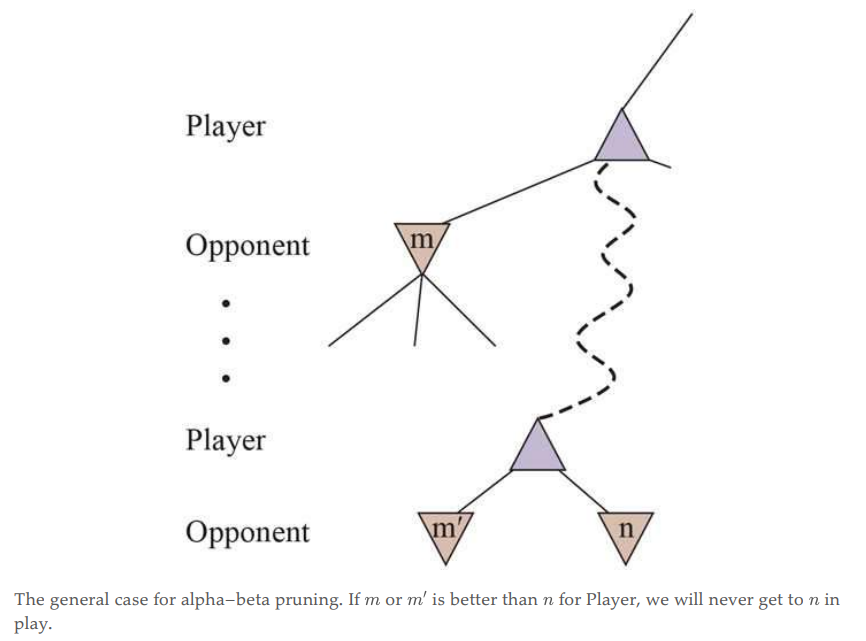

# Alpha–Beta Pruning and Game Strategies

## Mechanics of Alpha–Beta Pruning

Alpha–beta pruning improves minimax by maintaining bounds during search.

• α (alpha) — best (highest) value found so far for MAX; a lower bound on MAX’s achievable value.  
• β (beta) — best (lowest) value found so far for MIN; an upper bound on MAX’s achievable value.

During search, α and β are updated along the current path.  
Pruning occurs when a node’s value is guaranteed to be worse than the current bound.  
If MAX already has a better option elsewhere (value ≥ β), or MIN has a worse option elsewhere (value ≤ α), that subtree is discarded without further exploration.

## Impact of Move Ordering

Pruning efficiency depends heavily on move order.

• Perfect move ordering reduces time complexity from O(b^m) to O(b^(m/2)), effectively doubling reachable depth.  
• Heuristics such as the killer move heuristic and iterative deepening improve ordering and approach this theoretical bound.

## Type A and Type B Strategies (Claude Shannon, 1950)

### Type A (Wide and Shallow)
• Searches all legal moves to a fixed depth.  
• Uses heuristic evaluation at cutoff depth.  
• Historically dominant in chess, combined with alpha–beta pruning to maximize depth across full breadth.

### Type B (Deep and Narrow)
• Selectively explores promising moves while ignoring moves that appear poor.  
• Uses forward pruning and singular extensions.  
• Designed for high branching-factor games (e.g., Go).  
• Modern systems like AlphaZero demonstrate strong performance using selective deep search.

## Summary

Alpha–beta pruning is a Type A optimization that removes provably irrelevant nodes.  
Type B methods use heuristic pruning to explore deeper lines, sacrificing guaranteed optimality for greater depth.


# Monte Carlo Tree Search (MCTS)

Monte Carlo Tree Search is a randomized search strategy used in games with very large branching factors or where good heuristic evaluation functions are difficult to define (e.g., Go).

## Core Concept: Playout-Based Evaluation

Instead of using a heuristic at non-terminal states, MCTS estimates value by averaging outcomes from many simulations.

• Simulation (Playout/Rollout) — play from a state to a terminal position.  
• Playout Policy — selects moves during simulation, often combining randomness with learned bias (e.g., neural networks).  
• Win Percentage — for binary outcomes, value is estimated as empirical win rate.

## Four-Step Iterative Process

MCTS incrementally grows a search tree through repeated iterations:

1. Selection — starting from the root, choose moves via a selection policy until reaching a leaf.  
2. Expansion — add one or more child nodes to the tree.  
3. Simulation — perform a playout from the new node (not stored in the tree).  
4. Backpropagation — update statistics (wins and visit counts) along the path to the root.

## Exploration vs Exploitation

MCTS must balance:

• Exploitation — favor moves with high observed win rates.  
• Exploration — favor moves with few simulations to reduce uncertainty.

The common selection rule is UCT (Upper Confidence Bounds applied to Trees), using:

UCB1(n) = U(n)/N(n) + C * sqrt(ln N(parent(n)) / N(n))

where:  
• U(n) = total utility  
• N(n) = number of visits  
• C = exploration constant  

## Strengths and Weaknesses

Advantages:  
• More robust to single-node evaluation errors than alpha–beta.  
• Requires little domain-specific heuristic knowledge.  
• Works well in high branching-factor games.

Disadvantages:  
• May miss critical lines if early simulations undervalue them.  
• Can struggle with forced wins that require long verification.

**The general idea of simulating moves into the future, observing the outcome, and using the outcome to determine which mvoes are good ones is a kind of *reinforcement learning***


# 5.5 Stochastic Games

Stochastic games include random events (e.g., dice, shuffled cards). Example: backgammon.

• Chance nodes — represent random outcomes; branches labeled with probabilities.  
• Expectiminimax — generalizes minimax to handle chance:

EXPECTIMINIMAX(s) = Σ_r P(r) × EXPECTIMINIMAX(RESULT(s,r))

• Evaluation functions — must be a positive linear transformation of win probability; nonlinear scaling can change decisions and produce suboptimal play.

# 5.6 Partially Observable Games

The agent does not know the full state and must reason under uncertainty.

• Belief state — set of all states consistent with percept history.  
• Kriegspiel — invisible chess variant; a guaranteed checkmate works for all states in the belief state, while a probabilistic checkmate wins with probability 1 via randomized play.  
• Card games (poker, bridge) — often use averaging over clairvoyance, modeling the deal as a chance node and assuming full observability afterward.  
• Limitation of clairvoyance — ignores value of information; cannot model scouting, concealment, or bluffing.

# 5.7 Limitations of Game Search Algorithms

Despite strong performance, search algorithms have key limitations:

• Heuristic vulnerability — alpha–beta depends on accurate evaluation; a single error can mislead the search.  
• Need for metareasoning — algorithms often evaluate all moves even when one is clearly superior; ideally they would weigh computational cost vs benefit.  
• Move-level reasoning — current systems focus on individual moves, unlike humans who reason via higher-level plans and goals.  
• Knowledge acquisition — older systems relied on expert-crafted evaluation and opening books; modern systems (e.g., AlphaZero) learn from self-play but require massive computational resources.
